# Evaluix Testing Notebook

This notebook is set up to test Evaluix functionalities as if it were pip-installed.

In [1]:
# Import the main package and check version  # noqa: EXE002
import evaluix

print(f"Evaluix version: {evaluix.__version__}")
print(f"Package location: {evaluix.__file__}")

Evaluix version: 0.9.3.2
Package location: /workspace/src/evaluix/__init__.py


## Import Utility Modules

Import specific utility modules from the evaluix package:

In [2]:
# Import utility modules
# You can also use absolute imports
import evaluix.utils.CreateEvaluixConfig as ConfigModule
from evaluix.utils import file_loader, support_functions
from evaluix.utils import hysteresis_functions as hf

print("✓ Utility modules imported successfully")

✓ Utility modules imported successfully


## Import GUI Modules (Optional)

GUI components can be imported if needed (may require display):

In [4]:
# # Import GUI modules (uncomment if needed)
# from evaluix.GUIs import CustomWidgets
# # from evaluix.GUIs import FunctionViewer
# # from evaluix.GUIs import HDF5Preview

# print("✓ GUI modules imported successfully")

## Test Your Code Here

Add your test code below to experiment with Evaluix functions:

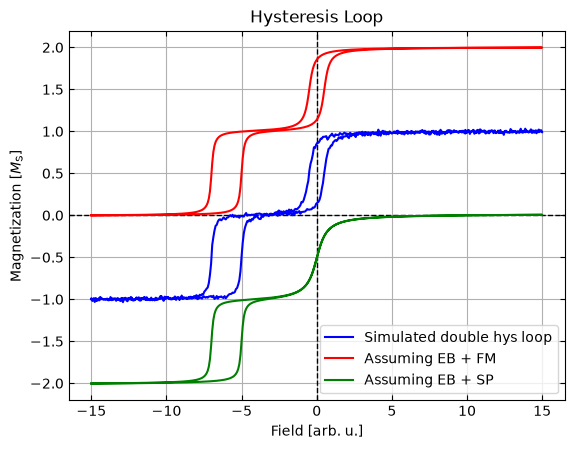

In [3]:
# Your test code here
import matplotlib.pyplot as plt
import numpy as np

# Define the parameters
asc_params_loop1 = {"a": 0, "b": 2.0, "c": 4.0, "d": 0, "e": 0.5}
desc_params_loop1 = {"a": 0, "b": 2.0, "c": 4.0, "d": 0, "e": -0.5}
asc_params_loop2 = {"a": 0, "b": 2.0, "c": 8.0, "d": -6.0, "e": 1}
desc_params_loop2 = {"a": 0, "b": 2.0, "c": 8.0, "d": -6.0, "e": -1}

asc_field = np.linspace(-15, 15, 400)
desc_field = np.linspace(15, -15, 400)
asc_branch = hf.arctan(asc_field, **asc_params_loop1) + hf.arctan(asc_field, **asc_params_loop2)
# invert field data and param e for descending branch
desc_branch = hf.arctan(desc_field, **desc_params_loop1) + hf.arctan(desc_field, **desc_params_loop2)

# combine the data to a full hysteresis loop
fields = np.concatenate([asc_field, desc_field])
magnetization = np.concatenate([asc_branch, desc_branch])

# Add a bit of noise to make it more realistic
noise = np.random.normal(0, 0.05, size=fields.shape)
magnetization += noise

# normalize the magnetization to the saturation magnetization of the whole loop
magnetization = hf.hys_norm(fields, magnetization)

# Fit the hysteresis loop using the mult_tan_hyseval of evaluix.utils.HysteresisFunctions
fitted_data, params, result = hf.mult_arctan_hyseval(fields, magnetization, arctan_types=['EB', 'FM'])
fitted_data2, params2, result2 = hf.mult_arctan_hyseval(fields, magnetization, arctan_types=['EB', 'SP'])

plt.figure()
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.plot(fields, magnetization, label='Simulated double hys loop', color='blue')
plt.plot(fitted_data['xdata'], fitted_data['ydata']+1, label='Assuming EB + FM', color='red')
plt.plot(fitted_data2['xdata'], fitted_data2['ydata']-1, label='Assuming EB + SP', color='green')
plt.xlabel('Field [arb. u.]')
plt.ylabel(r'Magnetization [$M_\mathrm{S}$]')
plt.title('Hysteresis Loop')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.legend()
plt.grid()
plt.show()

In [13]:
import numpy as np
import pandas as pd

In [14]:
hf.invert_axis(pd.DataFrame([1, 2, 3]), pd.DataFrame([4, 5, 6]), axis='x')

(   0
 0 -1
 1 -2
 2 -3,
    0
 0  4
 1  5
 2  6)

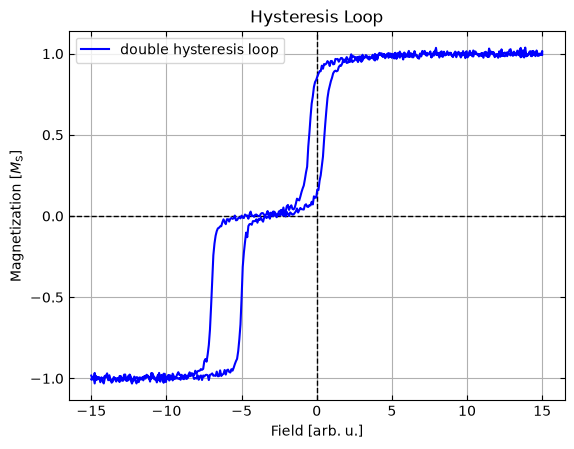

In [9]:
fields, magnetization = hf.invert_axis(fields, magnetization, 'both')

# plot with inverted axis
plt.figure()
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.plot(fields, magnetization, label='double hysteresis loop', color='blue')
plt.xlabel('Field [arb. u.]')
plt.ylabel(r'Magnetization [$M_\mathrm{S}$]')
plt.title('Hysteresis Loop')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.legend()
plt.grid()
plt.show()

/workspace/src/evaluix/utils/hysteresis_functions.py:3111: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


<Axes: xlabel='H [arb. u.]', ylabel='M [arb. u.]'>

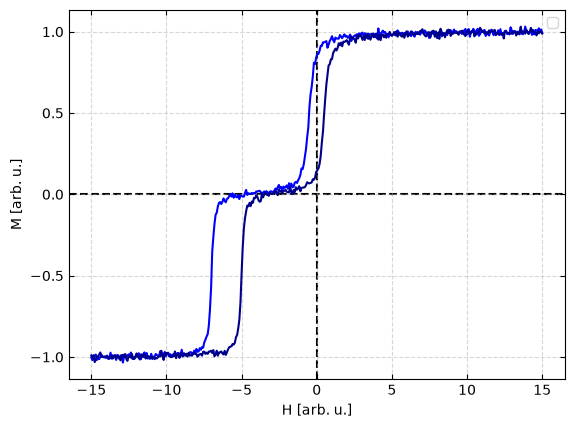

In [4]:
fig, ax = plt.subplots()
hf.plot_loop(fields, magnetization, ax)